# Object Detection and Image Segmentation

In [1]:
##############
## INSTALLS ##
##############

# Adjust the below install statement as needed the first time you run this notebook
# in order to install the needed libraries.
# !pip3 install opencv-python ultralytics kagglehub segmentation_models_pytorch

In [2]:
#############
## IMPORTS ##
############
# Computer vision library
import cv2
# Allows us to import data straight from kaggle without downloading
# the zip file. Note these files are still downloaded but they are
# stored in cache.
import kagglehub
# Plotting
import matplotlib.pyplot as plt
import os
# PIL, Pillow for image manipulation
from PIL import Image
# Access to U-net for image segmentation
import segmentation_models_pytorch as smp
# Torch and its normal imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import transforms, datasets
import torchvision.transforms.functional as TF
# The YOLO model
from ultralytics import YOLO

In [12]:
##################
## DEVICE SETUP ##
##################

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

## Object Detection

The goal of object detection is to determine where in an image there are objects and what that object is. This does not do a pixel by pixel location but rather it puts a bounding box around any objects based on a confidence interval.

In [3]:
###########
## YOLO ##
##########

# The goal of object detection is to answer two main questions:
#      a. What objects are in an image? (Classification)
#      b. Where are those objects located? (Localization with bounding boxes)

# YOLO, which stands for "You Only Look Once," is a real-time object detection algorithm.
# It's widely used in computer vision tasks for identifying and localizing objects within 
# images or videos. YOLO works by simultaneously predicting bounding boxes and class probabilities
# for multiple objects in a single forward pass of the neural network (single forward pass = you
# only look once). This makes YOLO extremely fast compared to other object detection algorithms as
# it doesn't require multiple passes over the image and uses a single convolutional neural network (CNN).

# YOLO works well for larger objects and general detection tasks, making it popular in applications
# like surveillance, self-driving cars, and robotics. However, it can struggle with small objects or
# overlapping objects compared to other algorithms like Faster R-CNN.

# YOLO was traditionally trained on datasets like COCO (Common Objects in Context), which contains a wide variety
# of everyday objects in diverse settings. This helps YOLO generalize well to different environments and
# object appearances. Its architecture is a single convolutional neural network that divides the input image into a grid.
# Each grid cell is responsible for predicting a fixed number of bounding boxes and class probabilities for objects
# whose centers fall within the cell.


# Load a pretrained YOLOv5 model from the ultralytics library. In addition to "yolov5s.pt", other variants include: 
# "yolov5n.pt" (nano, smallest and fastest), "yolov5m.pt" (medium), "yolov5l.pt" (large), and "yolov5x.pt" (extra large, most accurate).
model = YOLO("yolov5su.pt")  # small, fast, good for demos


In [4]:
################################
## IMPORT DATASET FROM KAGGLE ##
################################

# The below code downloads an object detection dataset from Kaggle. The dataset consists of images
# containing people and vehicles, along with corresponding annotations in YOLO format. The dataset
# is useful for training and evaluating object detection models, particularly for applications
# involving pedestrian and vehicle detection. 

# Though the data set contains the labels needed to train a YOLO model, in this notebook we will
# just use it to test the pretrained model loaded above. As an extension of these notes you could
# train your own YOLO model using this dataset or continue the training of the pretrained model.

# Import the dataset from Kaggle, this will store it in your cache directory for kagglehub.  You can
# check where this is located by running `kagglehub.cache_dir()` in a separate code cell but it should
# be in your home directory by default in a folder called .cache/kagglehub/datasets.
# Download size is  ~300MB
dataset_path = kagglehub.dataset_download("haseebhsb/yolo-person-vehicle-detection-dataset-annotated")
print("Dataset path:", dataset_path)
print("Files:", os.listdir(dataset_path))

# Define the path to the training images. This will be different based on where kagglehub
# stores the dataset on your machine and will be different for each dataset depending on the
# folder heirarchy used in the dataset. This is what works on my machine for this dataset and
# should work for you as well. If you use a different dataset you will need to adjust this path
# accordingly. Note that the strings being joined here correspond to the folder structure of the
# dataset as stored by kagglehub.

# Note that the dataset contains both training and validation images. Here we are just
# looking at the training images since we are just testing the pretrained model.
image_dir = os.path.join(dataset_path, "yolo-person-vehicle-dataset", "dataset", "images", "train")
image_files = os.listdir(image_dir)

# Print the number of images found in the training directory
print("Number of images:", len(image_files))

Dataset path: /Users/butlerju/.cache/kagglehub/datasets/haseebhsb/yolo-person-vehicle-detection-dataset-annotated/versions/1
Files: ['yolo-person-vehicle-dataset']
Number of images: 1600



0: 448x640 7 persons, 1 truck, 1 sports ball, 57.2ms
Speed: 1.5ms preprocess, 57.2ms inference, 1.6ms postprocess per image at shape (1, 3, 448, 640)


(np.float64(-0.5), np.float64(639.5), np.float64(426.5), np.float64(-0.5))

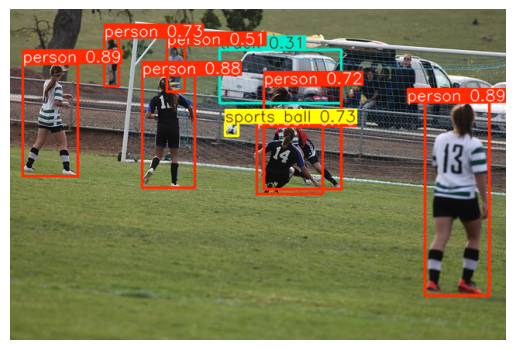

In [5]:
############################
## ANALYZE A SAMPLE IMAGE ##
#############################

# Load and preprocess a sample image from the dataset. In this case we are just loading
# the first image in the training directory but try a few different indices to see how
# the model does on different images.
image_path = os.path.join(image_dir, image_files[0])

# Load the image using OpenCV and convert it from BGR to RGB format. This is needed because
# OpenCV loads images in BGR format by default, while most deep learning models, including
# YOLO, expect images in RGB format (basically just reorder how the colors are ordered).
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

# Pass the image through the YOLO model to get predictions
results = model(image)

# Visualize the results by plotting bounding boxes and labels on the image. This is done
# using the `plot` method of the first result object, which returns an annotated image. Note
# that this is a feature of the ultralytics YOLO implementation that makes visualization easy.
# This is not standard across all YOLO implementations.
annotated_image = results[0].plot()

# Display the annotated image using matplotlib
plt.imshow(annotated_image)
plt.axis("off")

# Each time you run this cell you should see the image with bounding boxes. The color of the
# bounding boxes indicates the class of the detected object (e.g., person, car, bicycle). The 
# labels and confidence scores are also displayed above each bounding box. The higher the 
# confidence score, the more certain the model is about its prediction.

# In addition to looking at the objects the model detects, pay attention to the confidence scores 
# and and objects in the image that may have been missed. This can give you insight into the model's
# strengths and weaknesses, such as which types of objects it detects well and which ones it struggles
# with. Remember that YOLO is bad with small objects and overlapping objects so look for those. Also
# remember that this is a pretrained model so it may not do well on all images in this dataset.

In [6]:
############################################
## PRINT DETAILS ABOUT THE ABOVE ANALYSIS ##
# ##########################################
#     
# Extract and print detailed information about the detected objects, including bounding box 
# coordinates, confidence scores, and class indices.
boxes = results[0].boxes

print("Bounding boxes (x1, y1, x2, y2):")
print(boxes.xyxy)

print("\nConfidence scores:")
print(boxes.conf)

print("\nClass indices:")
print(boxes.cls)

# Get the names of the classes from the model
class_names = model.names
# Map class indices to class names and print them
detected_classes = [class_names[int(c)] for c in boxes.cls]
print("Detected objects:")
for obj in detected_classes:
    print(obj)


Bounding boxes (x1, y1, x2, y2):
tensor([[535.9341, 120.4439, 618.8478, 369.6899],
        [ 16.0999,  70.6047,  87.5818, 215.8960],
        [170.9541,  85.8314, 238.7160, 230.0108],
        [277.4104, 147.0419, 294.5258, 163.7511],
        [121.6258,  37.8249, 140.8580,  99.7775],
        [327.6107,  98.2726, 427.9952, 232.5129],
        [318.0168, 151.9220, 403.9403, 238.8836],
        [202.8836,  47.5129, 225.9427, 106.5632],
        [270.3968,  52.0244, 427.0539, 121.8333]])

Confidence scores:
tensor([0.8885, 0.8873, 0.8793, 0.7342, 0.7280, 0.7200, 0.6966, 0.5143, 0.3109])

Class indices:
tensor([ 0.,  0.,  0., 32.,  0.,  0.,  0.,  0.,  7.])
Detected objects:
person
person
person
sports ball
person
person
person
person
truck



0: 448x640 7 persons, 1 truck, 1 sports ball, 74.4ms
Speed: 0.9ms preprocess, 74.4ms inference, 0.4ms postprocess per image at shape (1, 3, 448, 640)


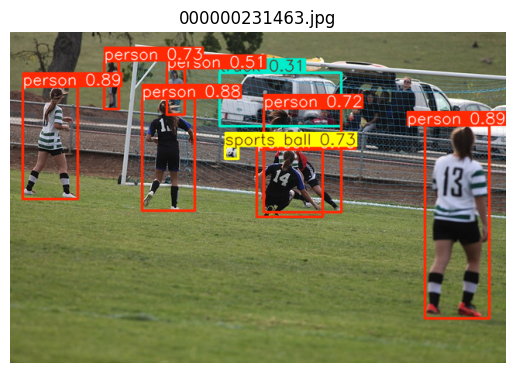


0: 480x640 1 person, 2 cars, 2 buss, 1 stop sign, 54.0ms
Speed: 0.9ms preprocess, 54.0ms inference, 0.4ms postprocess per image at shape (1, 3, 480, 640)


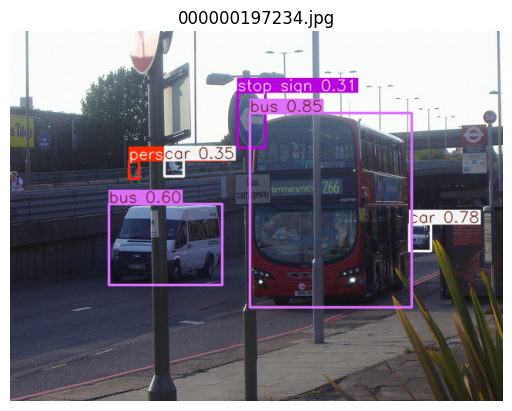


0: 480x640 6 cars, 1 truck, 1 parking meter, 55.6ms
Speed: 2.9ms preprocess, 55.6ms inference, 0.4ms postprocess per image at shape (1, 3, 480, 640)


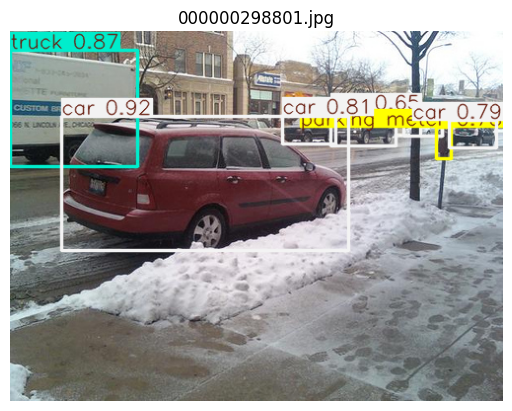


0: 448x640 3 persons, 2 cakes, 58.1ms
Speed: 1.2ms preprocess, 58.1ms inference, 0.4ms postprocess per image at shape (1, 3, 448, 640)


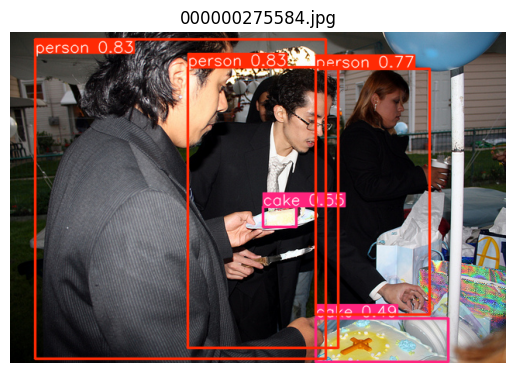


0: 480x640 2 persons, 1 surfboard, 54.7ms
Speed: 0.6ms preprocess, 54.7ms inference, 0.3ms postprocess per image at shape (1, 3, 480, 640)


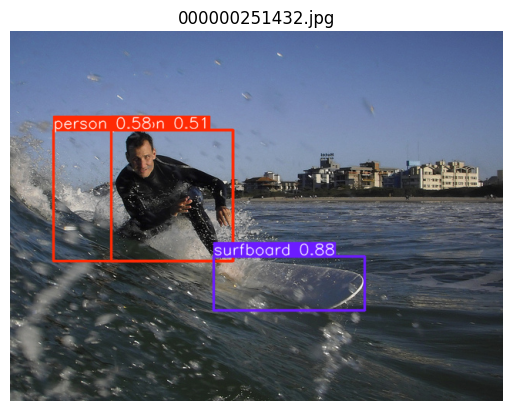

In [7]:
#########################
## ANALYZE MORE IMAGES ##
#########################

# Now let's analyze a few more images from the dataset to see how well the pretrained YOLO model 
# performs. Here I have set it to analyze the first 5 images in the training directory but feel 
# free to change this to any number of images you like.
for img_name in image_files[:5]:
    img_path = os.path.join(image_dir, img_name)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    results = model(img)
    annotated = results[0].plot()

    plt.imshow(annotated)
    plt.title(img_name)
    plt.axis("off")
    # plt.show is needed here since we want to display more than one
    # image in the output of the code cell. 
    plt.show()


## Image Segmentation

Image segmentation does not perform classification, but it goes further than object detection. Instead of just placing a bounding box around a detected object, the goal of image segmentation is to perform a pixel by pixel classification to determine exactly which pixels in the image belong to the object.

In [9]:
#########################
## IMPORT THE DATA SET ##
#########################

# For the next part of the notebook we will switch to image segmentation using U-net. 
# We will use the Oxford-IIIT Pet Dataset which contains images of 37 different breeds 
# of cats and dogs along with pixel-level annotations for each image. The goal of image 
# segmentation is to classify each pixel in the image as belonging to a specific class 
# (e.g., pet or background) rather than just drawing bounding boxes around objects as in 
# object detection. 

# The dataset can be downloaded using torchvision's datasets module. However, similarly
# annotated datasets can also be found on Kaggle if you wish to try those instead.

# This data set contains images of pets along with segmentation masks that label each pixel
# as either belonging to the pet or the background. The segmentation masks are provided
# as separate images where each pixel's value indicates the class (pet or background). Note
# the masks are images with the same height and width as the original images, but instead of 
# RGB values, each pixel's value corresponds to a class label (e.g., 1 for pet, 0 for background).
# It is important that the data type of the masks remain as integers so that we can compare
# them correctly during training.

# Define the directory to store the dataset. Once the dataset is downloaded it will
# be stored in this directory. Note that unlike the previous dataset we downloaded
# using kagglehub, this dataset is not stored in cache but rather in the specified
# directory. This also means that it will not be removed when you clear the kagglehub
# cache.
data_dir = "./oxford-iiit-pet"

# These are the transforms we will use for the images. We need to convert the images
# to tensors and resize them to a fixed size. The images need to be resized because
# U-net requires inputs of a fixed size. Here we resize to 128x128 pixels.
# Note that in a real application you would likely want to use a larger size
# for better accuracy but this size is chosen here to keep the computation low.
image_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

# These are the transforms for the segmentation masks. We need to resize them to the
# same size as the images and convert them to tensors. Note that we use
# interpolation=Image.NEAREST when resizing the masks to avoid introducing new pixel
# values that are not present in the original mask. Also note that we use a Lambda
# transform to convert the PIL image to a tensor manually since the default ToTensor
# transform converts the mask to a float tensor which is not what we want for segmentation.
mask_transform = transforms.Compose([
    transforms.Resize((128, 128), interpolation=Image.NEAREST),
    transforms.Lambda(lambda pic: TF.pil_to_tensor(pic))  # returns int tensor
])

# Import the training portion of the Oxford-IIIT Pet Dataset with the above transforms applied.
# Make sure the target_types is set to 'segmentation' so that we get the segmentation masks
# along with the images. There are other target types available such as 'category' for classification
# but for image segmentation we need 'segmentation'.
train_dataset = datasets.OxfordIIITPet(
    root=data_dir,
    split='trainval',
    target_types='segmentation',
    download=True,
    transform=image_transform,
    target_transform=mask_transform
)

# Create a DataLoader to load the data in batches. Here we set the batch size to 8
# and enable shuffling of the data.
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)



URLError: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1032)>

In [ ]:
############################
## DEFINE THE U-NET MODEL ##
############################

# The purpose of image segmentation is to classify each pixel in an image into a specific class,
# effectively partitioning the image into meaningful segments. This is useful in various 
# applications such as medical imaging (e.g., segmenting tumors), autonomous driving (e.g., 
# segmenting roads and pedestrians), and image editing (e.g., background removal).

# In this section we will define a U-net model for image segmentation using the 
# segmentation_models_pytorch library. We will use a pretrained encoder (backbone) for
# the U-net model to leverage transfer learning and improve performance.

#  U-net is a type of convolutional neural network architecture that is particularly well-suited 
# for image segmentation tasks.  It was originally developed for biomedical image segmentation 
# but has since been applied to  various other domains. U-net's architecture consists of two 
# main parts: a contracting path  (encoder) and an expansive path (decoder). The contracting 
# path captures context and extracts features from the input image through a series of convolutional 
# and pooling layers. The expansive path then upsamples the feature maps and combines them with 
# high-resolution features from the contracting path using skip connections. This allows the model 
# to produce precise segmentation maps that retain spatial information.

# Import a pretrained U-net model with a ResNet34 backbone. The model is set to take
# 3-channel RGB images as input and output segmentation masks with 3 classes (background, 
# pet, border). There are other backbones available such as resnet50, efficientnet, etc.
# using a pretrained backbone helps the model learn better features from the images,
# improving segmentation performance.
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=3  # background, pet, border
).to(device)



In [ ]:
###########################
## TRAIN THE U-NET MODEL ##
###########################
# Define the loss function and optimizer for training the U-net model.
loss_func = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# Training loop. Here I have set the number of epochs to 3 to get a shorter training
# time. In a real application you would likely want to train for more epochs to get
# better performance.
epochs = 3
for epoch in range(epochs):
    model.train()
    # Iterate over the training data loader, which provides batches of images and
    # their corresponding segmentation masks. The U-net model will learn to predict
    # the masks from the images, thus learning to segment the pets from the background.
    for images, masks in train_loader:
        # Move images and masks to the appropriate device (CPU or GPU)
        images = images.to(device)
        # Masks: (B,1,H,W) -> (B,H,W) and labels start from 0
        # The squeeze is needed to remove the channel dimension since the masks
        # are single-channel images. The long() converts the masks to integer type
        # since CrossEntropyLoss expects the target to be of type LongTensor.
        masks = masks.squeeze(1).long().to(device) - 1

        # Training step
        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_func(outputs, masks)
        loss.backward()
        optimizer.step()



In [ ]:
##############################
## EVALUATE THE U-NET MODEL ##
##############################

# Evaluate the trained U-net model on a batch of training images to see how well it
# performs segmentation. Here we just look at one batch from the training data loader.
# In a real application you would want to evaluate on a separate validation or test set.
# Adjusting split parameter of the datasets.OxfordIIITPet function will give you a test
# data set for more realistic evaluation.

model.eval()
# Get a batch of images and masks from the training data loader. The batch size is
# determined by the DataLoader defined earlier. The default batch size is 8 for this
# notebook.
images, masks = next(iter(train_loader))
images = images.to(device)

# For each image, generate segmentation predictions using the trained U-net model. The argmax
# is used to get the class with the highest probability for each pixel.
with torch.no_grad():
    outputs = model(images)
    preds = torch.argmax(outputs, dim=1)

NameError: name 'images' is not defined

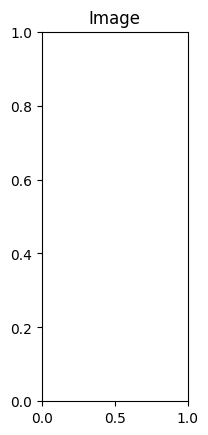

In [13]:
##############################
## VISUALIZATION OF RESULTS ##
##############################
# Visualize the original images, ground truth masks, and predicted masks side by side
# for the first 4 images in the batch.
for i in range(4):
    plt.subplot(1, 3, 1)
    plt.title("Image")
    plt.imshow(images[i].cpu().permute(1,2,0))
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.title("Ground Truth")
    plt.imshow(masks[i].squeeze().numpy(), cmap='gray')
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.title("Prediction")
    plt.imshow(preds[i].cpu(), cmap='gray')
    plt.axis("off")
    plt.show()
